# Imports and Setup

In [2]:
# 1. Imports and environment setup
import os
import random
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights, resnet18, ResNet18_Weights

import kagglehub

warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"

# Utility Functions

In [ ]:
# 2. Utility and visualization functions
def plot_training_history(train_loss, val_loss, train_acc, val_acc, title="Model Training Log"):
    fig, axes = plt.subplots(ncols=2, figsize=(15, 6))

    # Loss plot
    axes[0].plot(train_loss, label="Training", marker='o', ls='--')
    axes[0].plot(val_loss, label="Validation", marker='s')
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epochs")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1].plot(train_acc, label="Training", marker='o', ls='--')
    axes[1].plot(val_acc, label="Validation", marker='s')
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epochs")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def distillation_loss(student_logits, labels, teacher_logits, T=3.0, alpha=0.5):
    """
    T: Temperature to smooth probabilities
    alpha: Weight given to the teacher's loss (0.5 = balanced)
    """
    # Soft loss (Knowledge Distillation)
    # Apply temperature to log-probabilities
    soft_loss = nn.KLDivLoss(reduction='batchmean')(
        nn.functional.log_softmax(student_logits / T, dim=1),
        nn.functional.softmax(teacher_logits / T, dim=1)
    ) * (T * T)

    # Hard loss (Standard classification)
    hard_loss = nn.functional.cross_entropy(student_logits, labels)

    return alpha * soft_loss + (1.0 - alpha) * hard_loss

# Dataset Preparation

In [ ]:
# 3. Download and prepare the dataset
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Path to dataset files:", path)

def create_df(dataset_path):
    data_dict = {"images": [], "labels": []}
    for label in os.listdir(dataset_path):
        img_dir = os.path.join(dataset_path, label)
        if not os.path.isdir(img_dir): continue

        images = os.listdir(img_dir)
        index = 0
        for img in images:
            data_dict["images"].append(os.path.join(img_dir, img))
            data_dict["labels"].append(label)
            index += 1
            if index == 1000: # Limit to 1000 per class
                break
    return pd.DataFrame(data_dict)

train_path = "/kaggle/input/brain-tumor-mri-dataset/Training"
df = create_df(train_path)

# Label encoding
index_label = {i: label for i, label in enumerate(df["labels"].unique())}
label_index = {label: i for i, label in enumerate(df["labels"].unique())}
df["labels"] = df["labels"].map(label_index)

# Dataset Class
class BrainTumorDataset(Dataset):
    def __init__(self, data, transform):
        super(BrainTumorDataset, self).__init__()
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx, 0], self.data[idx, 1]
        img = Image.open(img_path).convert("RGB")
        img = self.transform(np.array(img))
        return img, label

# Hyperparameters & Transforms
IMG_SIZE = 224
BATCH = 16
OUT_SIZE = len(index_label)

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Splitting Data
train, val = train_test_split(df.values, random_state=42, test_size=0.25)
test, val = train_test_split(val, random_state=42, test_size=0.5)

train_dl = DataLoader(BrainTumorDataset(train, transform), batch_size=BATCH, shuffle=True)
val_dl = DataLoader(BrainTumorDataset(val, transform), batch_size=BATCH, shuffle=False)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


# Teacher Model Setup and Training (ResNet50)

Epoch 1 | Train Loss: 0.0594 | Train Acc: 0.8200 | Val Loss: 0.0543 | Val Acc: 0.9000
Epoch 2 | Train Loss: 0.0509 | Train Acc: 0.9360 | Val Loss: 0.0538 | Val Acc: 0.9020
Epoch 3 | Train Loss: 0.0497 | Train Acc: 0.9533 | Val Loss: 0.0517 | Val Acc: 0.9480
Epoch 4 | Train Loss: 0.0484 | Train Acc: 0.9737 | Val Loss: 0.0500 | Val Acc: 0.9740
Epoch 5 | Train Loss: 0.0479 | Train Acc: 0.9817 | Val Loss: 0.0583 | Val Acc: 0.8480
Epoch 6 | Train Loss: 0.0478 | Train Acc: 0.9830 | Val Loss: 0.0495 | Val Acc: 0.9660
Epoch 7 | Train Loss: 0.0475 | Train Acc: 0.9873 | Val Loss: 0.0502 | Val Acc: 0.9600
Epoch 8 | Train Loss: 0.0473 | Train Acc: 0.9900 | Val Loss: 0.0500 | Val Acc: 0.9660
Epoch 9 | Train Loss: 0.0471 | Train Acc: 0.9937 | Val Loss: 0.0511 | Val Acc: 0.9500
Epoch 10 | Train Loss: 0.0471 | Train Acc: 0.9937 | Val Loss: 0.0502 | Val Acc: 0.9640
Epoch 11 | Train Loss: 0.0470 | Train Acc: 0.9940 | Val Loss: 0.0502 | Val Acc: 0.9600
Epoch 12 | Train Loss: 0.0468 | Train Acc: 0.9977 | 

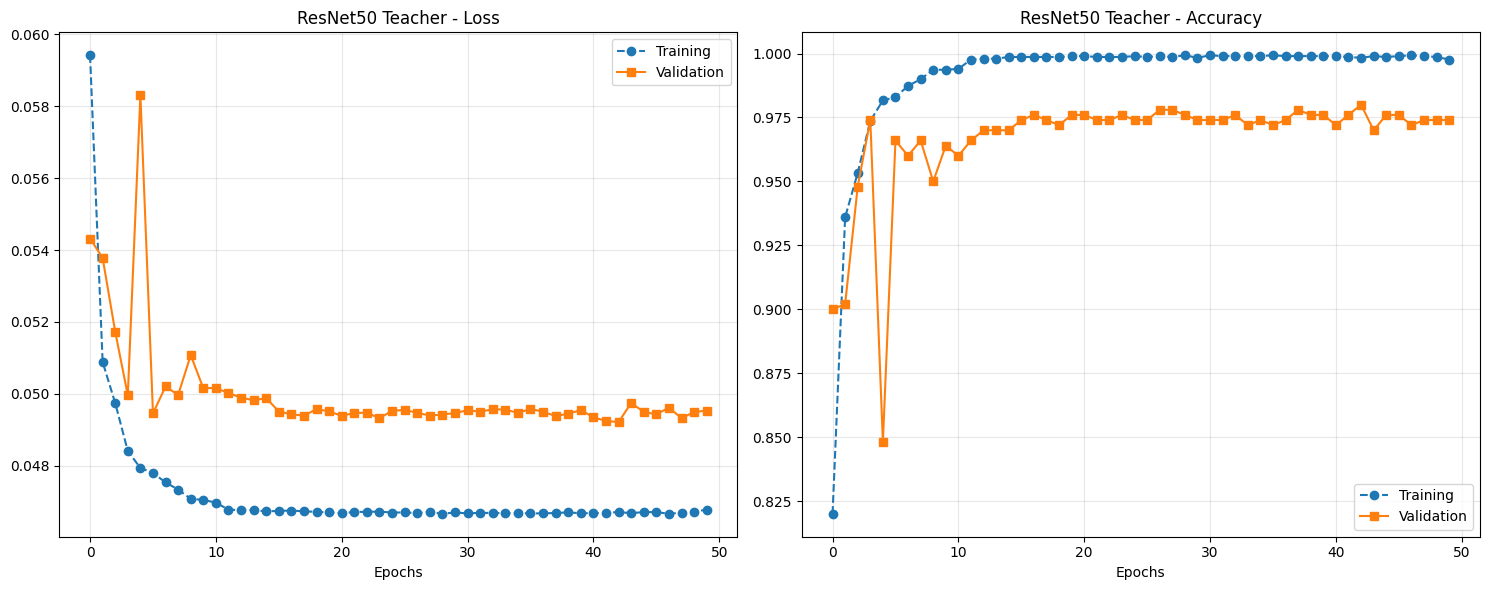

In [ ]:
# 4. Teacher Model initialization
class ResNetWrapper(nn.Module):
    def __init__(self, model):
        super(ResNetWrapper, self).__init__()
        self.model = model

    def forward(self, x):
        return nn.functional.softmax(self.model(x), dim=1)

resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
resnet.fc = nn.Linear(resnet.fc.in_features, OUT_SIZE)
teacher_model = ResNetWrapper(resnet).to(device)

# Training configurations
EPOCHS = 50
LR = 0.1
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(teacher_model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Training Loop
best_model = deepcopy(teacher_model)
best_acc = 0
train_loss, train_acc, val_loss, val_acc = [], [], [], []

for epoch in range(1, EPOCHS + 1):
    teacher_model.train()
    diff, acc, total = 0, 0, 0

    for data, target in train_dl:
        optimizer.zero_grad()
        data, target = data.to(device), target.to(device)

        out = teacher_model(data)
        loss = criterion(out, target)

        loss.backward()
        optimizer.step()

        diff += loss.item()
        acc += (out.argmax(1) == target).sum().item()
        total += out.size(0)

    train_loss.append(diff / total)
    train_acc.append(acc / total)

    # Validation Phase
    teacher_model.eval()
    diff, acc, total = 0, 0, 0

    with torch.no_grad():
        for data, target in val_dl:
            data, target = data.to(device), target.to(device)
            out = teacher_model(data)
            loss = criterion(out, target)
            diff += loss.item()
            acc += (out.argmax(1) == target).sum().item()
            total += out.size(0)

    val_loss.append(diff / total)
    val_acc.append(acc / total)

    # Save best model
    if val_acc[-1] >= best_acc:
        best_acc = val_acc[-1]
        best_model = deepcopy(teacher_model)

    scheduler.step()
    print(f"Epoch {epoch} | Train Loss: {train_loss[-1]:.4f} | Train Acc: {train_acc[-1]:.4f} | Val Loss: {val_loss[-1]:.4f} | Val Acc: {val_acc[-1]:.4f}")

plot_training_history(train_loss, val_loss, train_acc, val_acc, title="ResNet50 Teacher")

# Student Model Setup and Training (Knowledge Distillation)

In [ ]:
# ── FitNets : Feature-Based Distillation ──────────────────────────────────────

class StudentWithHint(nn.Module):
    """
    Wraps ResNet18 and adds a 1x1 conv regressor to match the teacher's
    hint layer output dimension (512 channels from ResNet50 layer2).
    """
    def __init__(self, base_model, teacher_hint_channels=512, student_hint_channels=128):
        super().__init__()
        self.model = base_model
        # Régressor : projette les features student (128) → teacher (512)
        self.regressor = nn.Conv2d(student_hint_channels, teacher_hint_channels, kernel_size=1)

    def forward(self, x):
        return nn.functional.softmax(self.model(x), dim=1)


# Re-initialiser le student avec le régressor FitNet
student_base_fitnets = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
student_base_fitnets.fc = nn.Linear(student_base_fitnets.fc.in_features, OUT_SIZE)
student_fitnets = StudentWithHint(student_base_fitnets).to(device)

print("Student FitNets initialisé.")
print(f"  Régressor: Conv2d(128 → 512, kernel=1)")

Student FitNets initialisé.
  Régressor: Conv2d(128 → 512, kernel=1)


# Extraction des features via hooks

In [ ]:
# ── Forward Hooks pour capturer les feature maps intermédiaires ───────────────

teacher_features = {}
student_features = {}

def make_hook(store_dict, key):
    def hook(module, input, output):
        store_dict[key] = output
    return hook

# On accroche sur layer2 (hint layer pour le teacher, guided layer pour le student)
# ResNet50 layer2 → 512 channels | ResNet18 layer2 → 128 channels
teacher_hook = best_model.model.layer2.register_forward_hook(
    make_hook(teacher_features, "hint")
)
student_hook = student_fitnets.model.layer2.register_forward_hook(
    make_hook(student_features, "guided")
)

print("Hooks enregistrés sur layer2 (teacher + student).")

Hooks enregistrés sur layer2 (teacher + student).


# Phase 1: FitNet Pre-training(loss sur features)

In [ ]:
# ── Phase 1 : FitNet Pre-training ─────────────────────────────────────────────
# Le student apprend à reproduire les feature maps du teacher via MSE.

EPOCHS_FITNETS_PHASE1 = 50
optimizer_fitnets = torch.optim.Adam(
    list(student_fitnets.model.parameters()) + list(student_fitnets.regressor.parameters()),
    lr=0.001
)
mse_loss = nn.MSELoss()

best_model.eval()  # Teacher figé

print("── Phase 1 : FitNet Pre-training (MSE sur features) ──")
for epoch in range(1, EPOCHS_FITNETS_PHASE1 + 1):
    student_fitnets.train()
    total_fitnets_loss = 0

    for data, target in train_dl:
        data, target = data.to(device), target.to(device)
        optimizer_fitnets.zero_grad()

        # Forward pass teacher (pour déclencher le hook, sans gradients)
        with torch.no_grad():
            _ = best_model(data)
        hint = teacher_features["hint"].detach()  # (B, 512, H, W)

        # Forward pass student (déclenche son hook)
        _ = student_fitnets(data)
        guided_raw = student_features["guided"]     # (B, 128, H, W)

        # Projection via régressor → (B, 512, H, W)
        guided_proj = student_fitnets.regressor(guided_raw)

        # FitNet Loss = MSE entre les feature maps
        loss = mse_loss(guided_proj, hint)

        loss.backward()
        optimizer_fitnets.step()
        total_fitnets_loss += loss.item()

    print(f"  Epoch {epoch} | FitNet Loss (MSE): {total_fitnets_loss / len(train_dl):.4f}")

print("\nPhase 1 terminée — le student imite les features du teacher.")

── Phase 1 : FitNet Pre-training (MSE sur features) ──
  Epoch 1 | FitNet Loss (MSE): 1.2744
  Epoch 2 | FitNet Loss (MSE): 0.6979
  Epoch 3 | FitNet Loss (MSE): 0.6090
  Epoch 4 | FitNet Loss (MSE): 0.5696
  Epoch 5 | FitNet Loss (MSE): 0.5466
  Epoch 6 | FitNet Loss (MSE): 0.5323
  Epoch 7 | FitNet Loss (MSE): 0.5223
  Epoch 8 | FitNet Loss (MSE): 0.5150
  Epoch 9 | FitNet Loss (MSE): 0.5088
  Epoch 10 | FitNet Loss (MSE): 0.5047
  Epoch 11 | FitNet Loss (MSE): 0.5010
  Epoch 12 | FitNet Loss (MSE): 0.4977
  Epoch 13 | FitNet Loss (MSE): 0.4953
  Epoch 14 | FitNet Loss (MSE): 0.4928
  Epoch 15 | FitNet Loss (MSE): 0.4906
  Epoch 16 | FitNet Loss (MSE): 0.4890
  Epoch 17 | FitNet Loss (MSE): 0.4878
  Epoch 18 | FitNet Loss (MSE): 0.4859
  Epoch 19 | FitNet Loss (MSE): 0.4845
  Epoch 20 | FitNet Loss (MSE): 0.4832
  Epoch 21 | FitNet Loss (MSE): 0.4809
  Epoch 22 | FitNet Loss (MSE): 0.4809
  Epoch 23 | FitNet Loss (MSE): 0.4797
  Epoch 24 | FitNet Loss (MSE): 0.4790
  Epoch 25 | FitNe

# Phase 2 : Fine-tuning avec distillation classique:

In [1]:
# ── Phase 2 : Fine-tuning avec KD Loss (Response-Based) ──────────────────────
# On affine le student avec la même distillation_loss que ton code original.

EPOCHS_FITNETS_PHASE2 = 50
optimizer_fitnets_ft = torch.optim.Adam(student_fitnets.model.parameters(), lr=0.0005)

print("── Phase 2 : Fine-tuning (KD Loss sur logits) ──")
for epoch in range(1, EPOCHS_FITNETS_PHASE2 + 1):
    student_fitnets.train()
    total_kd_loss = 0

    for data, target in train_dl:
        data, target = data.to(device), target.to(device)
        optimizer_fitnets_ft.zero_grad()

        with torch.no_grad():
            teacher_logits = best_model.model(data)   # raw logits teacher

        student_logits = student_fitnets.model(data)  # raw logits student

        loss = distillation_loss(student_logits, target, teacher_logits, T=3.0, alpha=0.7)

        loss.backward()
        optimizer_fitnets_ft.step()
        total_kd_loss += loss.item()

    print(f"  Epoch {epoch} | KD Loss: {total_kd_loss / len(train_dl):.4f}")

# Libérer les hooks (important !)
teacher_hook.remove()
student_hook.remove()

print("\nPhase 2 terminée — hooks supprimés.")

NameError: name 'torch' is not defined

# Model Evaluation & Inference


--- Classification Report ---
              precision    recall  f1-score   support

   pituitary       0.90      0.96      0.93       129
     notumor       0.96      0.96      0.96       126
  meningioma       0.96      0.78      0.86       131
      glioma       0.87      0.99      0.93       114

    accuracy                           0.92       500
   macro avg       0.92      0.92      0.92       500
weighted avg       0.92      0.92      0.92       500



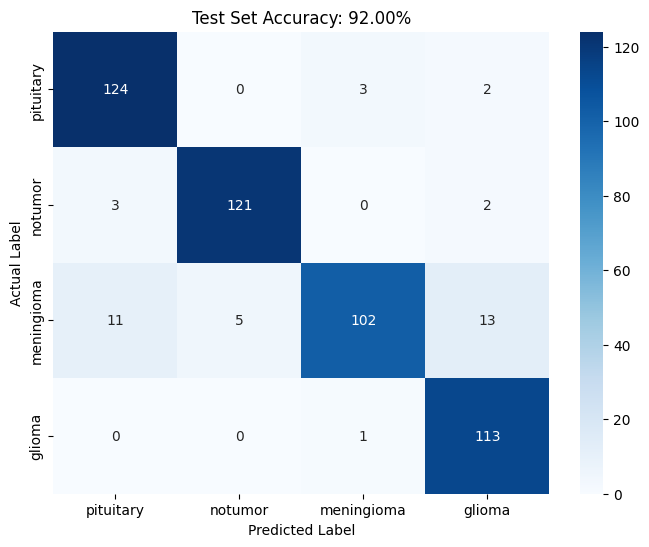


--- FitNets Student Classification Report ---
              precision    recall  f1-score   support

   pituitary       0.96      0.94      0.95       129
     notumor       0.98      0.95      0.97       126
  meningioma       0.96      0.76      0.85       131
      glioma       0.77      1.00      0.87       114

    accuracy                           0.91       500
   macro avg       0.92      0.91      0.91       500
weighted avg       0.92      0.91      0.91       500



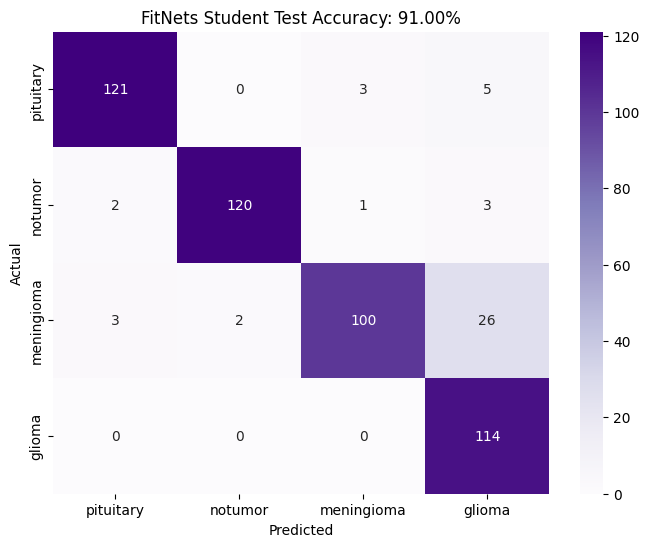

In [ ]:
# 6. Evaluation
def predict(img_path, model):
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(np.array(img)).view(1, 3, 224, 224).to(device)

    model.eval()
    with torch.no_grad():
        out = model(img_tensor)

    pred_idx = out.argmax(1).item()
    confidence = round(out[0][pred_idx].item() * 100, 2)
    return pred_idx, confidence

# Evaluate using the chosen model (using best_model / teacher here as per original code)
truth = []
preds = []

np.random.shuffle(test)

for i in range(test.shape[0]):
    truth.append(test[i, 1])
    pred, _ = predict(test[i, 0], best_model)
    preds.append(pred)

score = accuracy_score(truth, preds)
label_names = [index_label[i] for i in range(OUT_SIZE)]

print("\n--- Classification Report ---")
print(classification_report(truth, preds, target_names=label_names))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(truth, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title(f"Test Set Accuracy: {score:.2%}")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()



# Student evaluation

# ── Évaluation du Student FitNets ─────────────────────────────────────────────

truth_fitnets, preds_fitnets = [], []

for i in range(test.shape[0]):
    img = Image.open(test[i, 0]).convert("RGB")
    img_tensor = transform(np.array(img)).view(1, 3, 224, 224).to(device)

    student_fitnets.eval()
    with torch.no_grad():
        out = student_fitnets(img_tensor)

    truth_fitnets.append(test[i, 1])
    preds_fitnets.append(out.argmax(1).item())

score_fitnets = accuracy_score(truth_fitnets, preds_fitnets)
print("\n--- FitNets Student Classification Report ---")
print(classification_report(truth_fitnets, preds_fitnets, target_names=label_names))

plt.figure(figsize=(8, 6))
cm_fn = confusion_matrix(truth_fitnets, preds_fitnets)
sns.heatmap(cm_fn, annot=True, fmt='d', cmap='Purples',
            xticklabels=label_names, yticklabels=label_names)
plt.title(f"FitNets Student Test Accuracy: {score_fitnets:.2%}")
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.show()

Metric               | Teacher (ResNet50)   | Student (ResNet18)  
-----------------------------------------------------------------
Parameters           | 23.52             M | 11.24             M
Latency (ms/img)     | 8.02               | 2.79              
Throughput (FPS)     | 124.63             | 358.95            


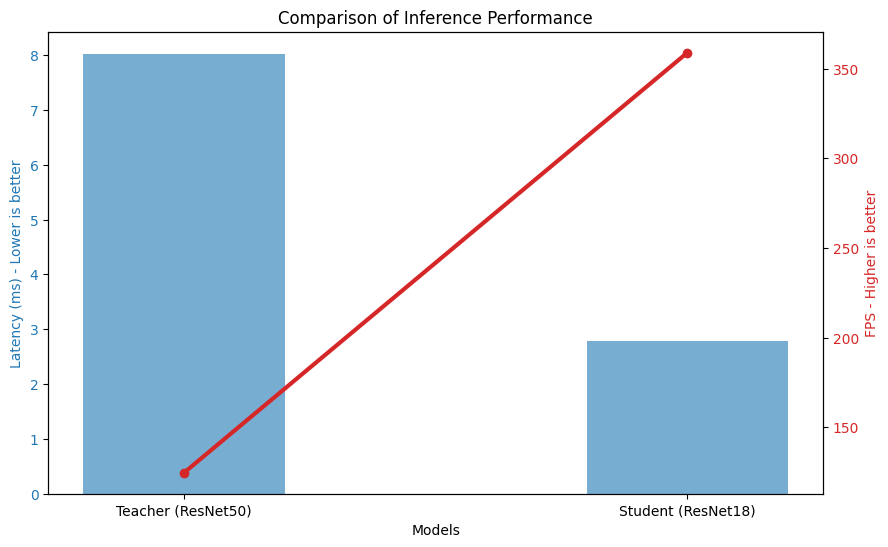

In [ ]:
import time

# 8. Inference Speed & Model Complexity Comparison
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def measure_inference_speed(model, device, input_size=(1, 3, 224, 224), iterations=100):
    model.eval()
    dummy_input = torch.randn(*input_size).to(device)

    # Warm-up (to initialize CUDA kernels)
    for _ in range(10):
        _ = model(dummy_input)

    torch.cuda.synchronize() if device == "cuda" else None
    start_time = time.time()

    with torch.no_grad():
        for _ in range(iterations):
            _ = model(dummy_input)
            if device == "cuda":
                torch.cuda.synchronize()

    end_time = time.time()
    total_time = end_time - start_time
    avg_latency = (total_time / iterations) * 1000 # in milliseconds
    fps = iterations / total_time

    return avg_latency, fps

# Calculations
params_teacher = count_parameters(teacher_model)
params_student = count_parameters(student_fitnets)

latency_t, fps_t = measure_inference_speed(teacher_model, device)
latency_s, fps_s = measure_inference_speed(student_fitnets, device)

# Results Summary
print(f"{'Metric':<20} | {'Teacher (ResNet50)':<20} | {'Student (ResNet18)':<20}")
print("-" * 65)
print(f"{'Parameters':<20} | {params_teacher/1e6:<18.2f}M | {params_student/1e6:<18.2f}M")
print(f"{'Latency (ms/img)':<20} | {latency_t:<18.2f} | {latency_s:<18.2f}")
print(f"{'Throughput (FPS)':<20} | {fps_t:<18.2f} | {fps_s:<18.2f}")

# Visualization
labels = ['Teacher (ResNet50)', 'Student (ResNet18)']
latencies = [latency_t, latency_s]
fps_values = [fps_t, fps_s]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Latency Bar Chart
color = 'tab:blue'
ax1.set_xlabel('Models')
ax1.set_ylabel('Latency (ms) - Lower is better', color=color)
ax1.bar(labels, latencies, color=color, alpha=0.6, width=0.4, label='Latency')
ax1.tick_params(axis='y', labelcolor=color)

# FPS Line Chart (Twin axis)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('FPS - Higher is better', color=color)
ax2.plot(labels, fps_values, color=color, marker='o', linewidth=3, label='FPS')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Comparison of Inference Performance')
plt.show()